# SVR for AOR Prediction - Jupyter Notebook

In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.svm import SVR
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import matplotlib.pyplot as plt
from sklearn.model_selection import GridSearchCV

In [2]:
# Import the function from the external file
from data.extract_data import extract_sections_by_elements

%load_ext autoreload
%autoreload 2

In [112]:
# Call the function to extract sections by element
elements_data = extract_sections_by_elements()

# Access the data for 'Paracetamol' and 'SingleF'
paracetamol_singlef_data = elements_data['SingleF']['Paracetamol']
print(paracetamol_singlef_data)

# Example: Access data for 'SingleF' and 'Paracetamol'
singlef_paracetamol_data = pd.concat([elements_data['SingleF']['Paracetamol'].dropna(how='all'), elements_data['BBD']['Paracetamol'].dropna(how='all')], ignore_index=True)
# print(singlef_paracetamol_data)

# # Example: Access data for 'BBD' and 'EC'
# bbd_ec_data = sections_data['BBD']['EC']
# print(bbd_ec_data)

      A        B    C     D             E    F    G     AOR Comment
1   0.2  0.00005  0.4  0.28  4.000000e-07  0.3  0.6  40.250     NaN
2   0.3  0.00005  0.4  0.28  4.000000e-07  0.3  0.6  42.305     NaN
3   0.4  0.00005  0.4  0.28  4.000000e-07  0.3  0.6  43.680     NaN
4   0.5  0.00005  0.4  0.28  4.000000e-07  0.3  0.6  43.605     NaN
5   0.6  0.00005  0.4  0.28  4.000000e-07  0.3  0.6  43.215     NaN
..  ...      ...  ...   ...           ...  ...  ...     ...     ...
58  NaN      NaN  NaN   NaN           NaN  NaN  NaN     NaN     NaN
59  NaN      NaN  NaN   NaN           NaN  NaN  NaN     NaN     NaN
60  NaN      NaN  NaN   NaN           NaN  NaN  NaN     NaN     NaN
61  NaN      NaN  NaN   NaN           NaN  NaN  NaN     NaN     NaN
62  NaN      NaN  NaN   NaN           NaN  NaN  NaN     NaN     NaN

[62 rows x 9 columns]


In [114]:
paracetamol_singlef_data = elements_data['SingleF']['Paracetamol'].iloc[:, :-1].dropna(how='all')
paracetamol_pb_data = elements_data['PB']['Paracetamol'].iloc[:, :-1].dropna(how='all')
paracetamol_climbing_data = elements_data['Climbing']['Paracetamol'].iloc[:, :-1].dropna(how='all')
paracetamol_bbd_data = elements_data['BBD']['Paracetamol'].iloc[:, :-1].dropna(how='all')
paracetamol_verification_data = elements_data['Verification']['Paracetamol'].iloc[:, :-1].dropna(how='all')
print(paracetamol_verification_data)

       A         B    C      D             E    F      G      AOR
106  0.4  0.000061  0.4  0.359  4.000000e-07  0.4  0.347  42.9125
107  0.4  0.000060  0.4  0.366  4.000000e-07  0.4  0.399  43.6300
108  0.4  0.000062  0.4  0.337  4.000000e-07  0.4  0.395  40.9125


In [115]:
ec_singlef_data = elements_data['SingleF']['EC'].iloc[:, :-2].dropna(how='all')
ec_pb_data = elements_data['PB']['EC'].iloc[:, :-2].dropna(how='all')
ec_climbing_data = elements_data['Climbing']['EC'].iloc[:, :-2].dropna(how='all')
ec_bbd_data = elements_data['BBD']['EC'].iloc[:, :-2].dropna(how='all')
ec_verification_data = elements_data['Verification']['EC'].iloc[:, :-2].iloc[:-1, :].dropna(how='all')
print(ec_bbd_data)

        A         B     C      D             E    F    G     AOR
87   0.80  0.000068  0.80  0.245  2.500000e-07  0.6  0.6  30.600
88   0.75  0.000068  0.75  0.245  2.500000e-07  0.6  0.6  33.555
89   0.75  0.000068  0.75  0.245  2.500000e-07  0.6  0.6  34.155
90   0.80  0.000068  0.75  0.220  2.500000e-07  0.6  0.6  31.095
91   0.75  0.000068  0.70  0.270  2.500000e-07  0.6  0.6  35.005
92   0.80  0.000068  0.70  0.245  2.500000e-07  0.6  0.6  34.370
93   0.75  0.000068  0.80  0.270  2.500000e-07  0.6  0.6  32.415
94   0.75  0.000068  0.75  0.245  2.500000e-07  0.6  0.6  33.675
95   0.80  0.000068  0.75  0.270  2.500000e-07  0.6  0.6  34.205
96   0.75  0.000068  0.70  0.220  2.500000e-07  0.6  0.6  33.595
97   0.75  0.000068  0.75  0.245  2.500000e-07  0.6  0.6  31.945
98   0.70  0.000068  0.75  0.220  2.500000e-07  0.6  0.6  32.580
99   0.70  0.000068  0.80  0.245  2.500000e-07  0.6  0.6  31.225
100  0.75  0.000068  0.75  0.245  2.500000e-07  0.6  0.6  34.470
101  0.70  0.000068  0.70

In [110]:
kollicoat_singlef_data = elements_data['SingleF']['Kollicoat'].dropna(how='all')
kollicoat_pb_data = elements_data['PB']['Kollicoat'].dropna(how='all')
kollicoat_climbing_data = elements_data['Climbing']['Kollicoat'].dropna(how='all')
kollicoat_bbd_data = elements_data['BBD']['Kollicoat'].dropna(how='all')
kollicoat_verification_data = elements_data['Verification']['Kollicoat'].iloc[:-1, :].dropna(how='all')
print(kollicoat_verification_data.columns)

Index(['A', 'B', 'C', 'D', 'E', 'F', 'G', 'AOR'], dtype='object')


In [111]:
peg8000_singlef_data = elements_data['SingleF']['PEG8000'].dropna(how='all')
peg8000_pb_data = elements_data['PB']['PEG8000'].dropna(how='all')
peg8000_climbing_data = elements_data['Climbing']['PEG8000'].dropna(how='all')
peg8000_bbd_data = elements_data['BBD']['PEG8000'].dropna(how='all')
peg8000_verification_data = elements_data['Verification']['PEG8000'].iloc[:-1, :].dropna(how='all')
print(peg8000_verification_data.columns)

Index(['A', 'B', 'C', 'D', 'E', 'F', 'G', 'AOR'], dtype='object')


In [116]:
combined_data_list = [paracetamol_singlef_data, paracetamol_pb_data, paracetamol_climbing_data, paracetamol_bbd_data, paracetamol_verification_data,
                     ec_singlef_data, ec_pb_data, ec_climbing_data, ec_bbd_data, ec_verification_data,
                     kollicoat_singlef_data, kollicoat_pb_data, kollicoat_climbing_data, kollicoat_bbd_data, kollicoat_verification_data,
                     peg8000_singlef_data, peg8000_pb_data, peg8000_climbing_data, peg8000_bbd_data, peg8000_verification_data]
combined_data = pd.concat(combined_data_list, ignore_index=True)
print(combined_data)

       A         B      C     D             E    F      G      AOR
0    0.2  0.000050  0.400  0.28  4.000000e-07  0.3  0.600  40.2500
1    0.3  0.000050  0.400  0.28  4.000000e-07  0.3  0.600  42.3050
2    0.4  0.000050  0.400  0.28  4.000000e-07  0.3  0.600  43.6800
3    0.5  0.000050  0.400  0.28  4.000000e-07  0.3  0.600  43.6050
4    0.6  0.000050  0.400  0.28  4.000000e-07  0.3  0.600  43.2150
..   ...       ...    ...   ...           ...  ...    ...      ...
350  0.2  0.000008  0.200  0.30  5.000000e-08  0.3  0.700  34.0975
351  0.2  0.000010  0.200  0.30  5.000000e-08  0.3  0.600  34.2800
352  0.2  0.000010  0.135  0.30  5.000000e-08  0.3  0.669  35.6400
353  0.2  0.000010  0.113  0.30  5.000000e-08  0.3  0.648  35.1900
354  0.2  0.000010  0.197  0.30  5.000000e-08  0.3  0.699  34.5525

[355 rows x 8 columns]


In [118]:
# X=singlef_paracetamol_data[['A:p-p fc', 'B:p-p se', 'C:p-p cr', 'D:p-w fc', 'E:p-w se', 'F:p-w cr', 'G:rr']]
X=combined_data[['A', 'B', 'C', 'D', 'E', 'F', 'G']]
y=combined_data['AOR']

In [119]:
X

,A,B,C,D,E,F,G
0,0.2,0.000050,0.400,0.28,4.000000e-07,0.3,0.600
1,0.3,0.000050,0.400,0.28,4.000000e-07,0.3,0.600
2,0.4,0.000050,0.400,0.28,4.000000e-07,0.3,0.600
3,0.5,0.000050,0.400,0.28,4.000000e-07,0.3,0.600
4,0.6,0.000050,0.400,0.28,4.000000e-07,0.3,0.600
...,...,...,...,...,...,...,...
350,0.2,0.000008,0.200,0.30,5.000000e-08,0.3,0.700
351,0.2,0.000010,0.200,0.30,5.000000e-08,0.3,0.600
352,0.2,0.000010,0.135,0.30,5.000000e-08,0.3,0.669
353,0.2,0.000010,0.113,0.30,5.000000e-08,0.3,0.648


In [120]:
# Split the data into training and testing sets (80% training, 20% testing)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Normalize the features
scaler = StandardScaler()

# Fit the scaler only on the training data, then transform both train and test data
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [121]:
# Initialize the SVR model with an RBF kernel
svr_model = SVR(kernel='rbf')

# Fit the model to the training data
svr_model.fit(X_train_scaled, y_train)

# Use the trained model to predict the AOR for the test set
y_pred = svr_model.predict(X_test_scaled)

# Calculate performance metrics
mse = mean_squared_error(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"Mean Squared Error (MSE): {mse}")
print(f"Mean Absolute Error (MAE): {mae}")
print(f"R-Squared (R2 Score): {r2}")

Mean Squared Error (MSE): 5.145588313653572
Mean Absolute Error (MAE): 1.5514620371564423
R-Squared (R2 Score): 0.8173403934602618


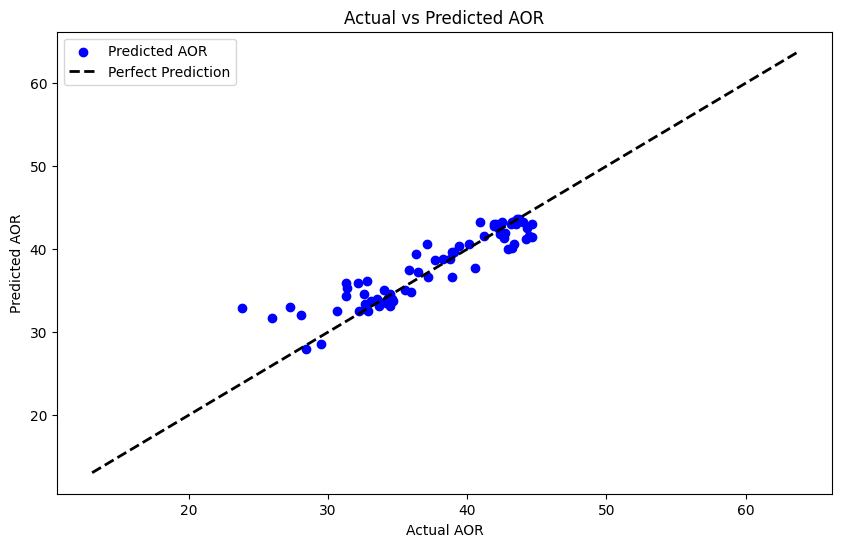

Fitting 5 folds for each of 24 candidates, totalling 120 fits
Best Parameters from GridSearch: {'C': 10, 'gamma': 'auto', 'kernel': 'rbf'}
Optimized Mean Squared Error (MSE): 2.69364437264161
Optimized Mean Absolute Error (MAE): 1.1831110602100234
Optimized R-Squared (R2 Score): 0.9043802202443703


In [122]:
# Plot the actual vs predicted values
plt.figure(figsize=(10,6))
plt.scatter(y_test, y_pred, color='blue', label='Predicted AOR')
plt.plot([y.min(), y.max()], [y.min(), y.max()], 'k--', lw=2, label='Perfect Prediction')
plt.xlabel('Actual AOR')
plt.ylabel('Predicted AOR')
plt.title('Actual vs Predicted AOR')
plt.legend()
plt.show()

# Define the parameter grid for SVR
param_grid = {
    'C': [0.1, 1, 10, 100],  # Regularization parameter
    'gamma': ['scale', 'auto'],  # Kernel coefficient
    'kernel': ['rbf', 'linear', 'poly']  # Different kernels to test
}

# Initialize GridSearchCV
grid_search = GridSearchCV(SVR(), param_grid, cv=5, scoring='neg_mean_squared_error', verbose=2, n_jobs=-1)

# Fit GridSearchCV to the training data
grid_search.fit(X_train_scaled, y_train)

# Display the best parameters from GridSearch
print("Best Parameters from GridSearch:", grid_search.best_params_)

# Re-train the model with the best parameters
best_svr_model = grid_search.best_estimator_
best_svr_model.fit(X_train_scaled, y_train)

# Make new predictions with the optimized model
y_pred_best = best_svr_model.predict(X_test_scaled)

# Evaluate the optimized model
mse_best = mean_squared_error(y_test, y_pred_best)
mae_best = mean_absolute_error(y_test, y_pred_best)
r2_best = r2_score(y_test, y_pred_best)

print(f"Optimized Mean Squared Error (MSE): {mse_best}")
print(f"Optimized Mean Absolute Error (MAE): {mae_best}")
print(f"Optimized R-Squared (R2 Score): {r2_best}")